In [1]:
#!/usr/bin/env python
# coding: utf-8

=============================================================
13 - Smoothing linear Levy transition models with the RTS and CK smoothers
=============================================================
In line with the tutorial examples of the Kalman and particle 
filters in Stone Soup, a simplified single-target tracking 
example without clutter is provided here to demonstrate the 
use of linear transition models driven by non-Gaussian Levy 
noise, as well as how to perform inference tasks on this class 
of models using the MarginalisedKalman and CarterKohn smoothers.

This tutorial extends the previous tutorial by introducing 
three smoother classes which allow for improved state 
estimation by taking future data into account.

Consider the scenario where the target evolves according to the Langevin model, driven by a normal sigma-mean mixture with the mixing distribution being the $\alpha$-stable distribution.


In [2]:
import numpy as np
from datetime import datetime, timedelta

The state of the target can be represented as 2D Cartesian coordinates, $\left[x, \dot x, y, \dot y\right]^{\top}$, modelling both its position and velocity. A simple truth path is created with a sampling rate of 1 Hz.


In [3]:
from stonesoup.types.groundtruth import GroundTruthPath, GroundTruthState
from stonesoup.models.base_driver import NoiseCase
from stonesoup.models.driver import AlphaStableNSMDriver 
from stonesoup.models.transition.levy_linear import LevyLangevin, CombinedLinearLevyTransitionModel

# And the clock starts
start_time = datetime.now().replace(microsecond=0)



See the tutorial on the Marginalised Particle Filter for greater depth into how the driving process ensures a groundtruth generated from the desired distribution, 
and how a track object of particles can be generated through the Kalman filtering recursion, conditional on sampled latent variables. 

This tutorial will follow the same filtering process as in the previous tutorial, 
but will focus on the subsequent smoothing functionalities of the ParticleSmoother, MarginalisedKalmanSmoother and CarterKohnSmoother classes. 

Additional functionality regarding plotting capabilities for Particle class tracks will be discussed as we progress through the tutorial. 


As mentioned in the previous tutorial, the `LevyLangevin` class creates a one-dimensional Langevin model, driven by the $\alpha$-stable NSM mixture process defined in the `AlphaStableNSMDriver` class.

\begin{equation}
d \dot{x}(t)=-\theta \dot{x}(t) d t+d W(t), \quad \theta>0
\end{equation}

where $\theta$ is the damping factor and $W(t)$ is the non-Gaussian driving process. 

In the Marginalised

The noise samples $\mathbf{w}_n$ are drawn from the $\alpha$-stable distribution parameterized by the $\alpha$-stable law, $S_{\alpha}(\sigma, \beta, \mu)$.

The input parameters to `AlphaStableNSMDriver` class are the stability index $\alpha$, expected jumps per unit time $c$, conditional Gaussian mean $\mu_W$ & variance $\sigma_W^2$, and the type of residuals used for the truncated shot-noise representation, specified by `noise_case`. 

Without diving into technical details, the scaling factor $\sigma$, skewness parameter $\beta$ and location $\mu$, in the $\alpha$-stable law is a function of the conditional Gaussian parameters $\mu_W, \sigma_W^2$. In general, set $\mu_W=0$ for a symmetric target distribution $\beta=0$, or $\mu_W \neq 0$ to model biased trajectories otherwise. In addition, the size of the resulting trajectories (and jumps) can be adjusted by varying $\sigma_W^2$.

The available noise cases are:

1. No residuals, `NoiseCase.TRUNCATED`, least expensive but drawn noise samples deviate further from target distribution.
2. `NoiseCase.GAUSSIAN_APPROX`, the most expensive but drawn noise samples closest target distribution.
3. `PartialNoiseCase.GAUSSIAN_APPROX`, a compromise between both cases (1) and (2).


For interested readers, refer to [1, 2] for more details.

Here, we initialise an $\alpha$-stable driver with the default parameters `mu_W=0, sigma_W2=1, alpha=1.4, noise_case=NoiseCase.GAUSSIAN_APPROX(), c=10`.

Then, the driver instance is injected into the Langevin model for every coordinate axes (i.e., x and y) during initialisation with parameter `damping_coeff=0.15`.

Note that we overwrite the default `mu_W` parameter in the $\alpha$-stable driver for the x-coordinate axes to bias our trajectories towards the left. This can be done by passing an additional argument `mu_W = -0.02` when injecting the driver into the Langevin model.

Finallt, the `CombinedLinearLevyTransitionModel` class takes a set of 1-D models and combines them into a linear transition model of arbitrary dimension, $D$, (in this case, $D=2$).




<!-- and  in the $\alpha$-stable law is a function of the conditional Gaussian mean $\mu_W$

where $\beta=\begin{cases} 1, \quad \mu_W \neq 0 \\ 0, \quad \text{otherwise} \end{cases}$ with $\beta=0$ being the a symmetric stable distribution.

$\sigma=\frac{\mathbb{E}|w|^\alpha \Gamma(2-\alpha) \cos(\pi \alpha / 2))}{1- \alpha}$ represent the scale parameter and $\beta=$ controlling the skewness of the stable distribution. -->



In [4]:
# We input the driver parameters, driver and driven models into our combined transition model
seed = 1 # Random seem for reproducibility

# Driving process parameters
mu_W = 0
sigma_W2 = 4
alpha = 1.4
c=10
noise_case=NoiseCase.GAUSSIAN_APPROX


# Model parameters
theta=0.15

driver_x = AlphaStableNSMDriver(mu_W=mu_W, sigma_W2=sigma_W2, seed=seed, c=c, alpha=alpha, noise_case=noise_case)
driver_y = driver_x # Same driving process in both dimensions and sharing the same latents (jumps)
langevin_x = LevyLangevin(driver=driver_x, damping_coeff=theta, mu_W=-0.02)
langevin_y = LevyLangevin(driver=driver_y, damping_coeff=theta)
transition_model = CombinedLinearLevyTransitionModel([langevin_x, langevin_y])



In [5]:
# The ground truth is initialised from (0). We then simulate a groundtruth path.
timesteps = [start_time]
truth = GroundTruthPath([GroundTruthState([0, 1, 0, 1], timestamp=timesteps[0])])
# The state of the target can be represented as 2D Cartesian coordinates, $\left[x, \dot x, y, \dot y\right]^{\top}$, modelling both its position and velocity. A simple truth path is created with a sampling rate of 1 Hz.

num_steps = 40
for k in range(1, num_steps + 1):
    timesteps.append(start_time+timedelta(seconds=k))  # add next timestep to list of timesteps
    truth.append(GroundTruthState(
        transition_model.function(truth[k-1], noise=True, time_interval=timedelta(seconds=1)),
        timestamp=timesteps[k]))

The simulated ground truth path can be plotted using the in-built plotting classes in Stone Soup.

Before we plot our groundtruth, we will outline a colours dictionary to ensure consistency across plots

In [6]:
colors_dict={}
colors_dict['truth']='blue'
colors_dict['track']='#00CC96'
colors_dict['culled_track']='#FFA15A'
colors_dict['RTS_track']='#B6E880'
colors_dict['CK_track']='#AB63FA'

In addition to the ground truth, Stone Soup plotting tools allow measurements and predicted tracks (see later) to be plotted and synced together consistently.

An animated plotter that uses Plotly graph objects can be accessed via the `AnimatedPlotterly` class from Stone Soup.

Note that the animated plotter requires a list of timesteps as an input, and that `tail_length`
is set to 0.3. This means that each data point will be on display for 30% of the total
simulation time. The mapping argument is [0, 2] because those are the x and y position indices from our state vector.

If a static plotter is preferred, the `Plotterly` class can be used instead

In [7]:
# from stonesoup.plotter import AnimatedPlotterly
# plotter = AnimatedPlotterly(timesteps, tail_length=1.0, width=800, height=600)

from stonesoup.plotter import Plotterly, Dimension
# We first plot the generated position components of the generated groundtruth.
xy_plotter= Plotterly(autosize=False, width=800,height=600, axis_labels=['x_position', 'y_position'])
xy_plotter.plot_ground_truths(truth, [0,2],line=dict(color=colors_dict['truth']))
xy_plotter.fig

1D plotting capabilities and smoother uncertainties

Plotting a single 1D component against time is also possible in Stone Soup by setting the dimension parameter equal to Dimension.ONE.

These plots may provide a clearer insight into how the underlying process evolves over time and 
(as we will see later), how the output for each smoothing classes differ.  

In [8]:
# Alongside the 2D position plot, we will look at a 1D plot of the x-velocity component, using mapping=[1]. 
x_vel_plotter= Plotterly(autosize=False, width=800,height=600,dimension=Dimension.ONE, axis_labels=['Time','x_velocity'])
x_vel_plotter.plot_ground_truths(truth, [1])
x_vel_plotter.fig

## Simulate measurements

Assume a 'linear' sensor which detects the
position, but not velocity, of a target, such that
$\mathbf{z}_k = H_k \mathbf{x}_k + \boldsymbol{\nu}_k$,
$\boldsymbol{\nu}_k \sim \mathcal{N}(0,R)$, with

\begin{align}H_k &= \begin{bmatrix}
                    1 & 0 & 0 & 0\\
                    0  & 0 & 1 & 0\\
                      \end{bmatrix}\\
          R &= \begin{bmatrix}
                  25 & 0\\
                    0 & 25\\
               \end{bmatrix} \omega\end{align}

where $\omega$ is set to 25 initially.




In [9]:

from stonesoup.types.detection import Detection
from stonesoup.models.measurement.linear import LinearGaussian

# The linear Gaussian measurement model is set up by indicating the number of dimensions in the
# state vector and the dimensions that are measured (so specifying $H_k$) and the noise
# covariance matrix $R$.

measurement_model = LinearGaussian(
    ndim_state=4,  # Number of state dimensions (position and velocity in 2D)
    mapping=(0, 2),  # Mapping measurement vector index to state index
    noise_covar=np.array([[25, 0],  # Covariance matrix for Gaussian PDF
                          [0, 25]])
    )


In [10]:
# The measurements can now be generated and plotted accordingly.

measurements = []
for state in truth:
    measurement = measurement_model.function(state, noise=True)
    measurements.append(Detection(measurement,
                                  timestamp=state.timestamp,
                                  measurement_model=measurement_model))


xy_plotter.plot_measurements(measurements, [0,2], marker=dict(symbol="x"))
xy_plotter.fig

## Marginalised Particle Filtering

The `MarginalisedParticlePredictor` and `MarginalisedParticleUpdater` classes correspond to the predict and update steps
respectively.
Both require a `TransitionModel` and a `MeasurementModel` instance respectively.
To avoid degenerate samples, the `SystematicResampler` is used which is passed to the updater.
More resamplers that are included in Stone Soup are covered in the
[Resampler Tutorial](https://stonesoup.readthedocs.io/en/latest/auto_tutorials/sampling/ResamplingTutorial.html#sphx-glr-auto-tutorials-sampling-resamplingtutorial-py).

In [11]:
from stonesoup.predictor.particle import MarginalisedParticlePredictor
from stonesoup.resampler.particle import SystematicResampler
from stonesoup.updater.particle import MarginalisedParticleUpdater

predictor = MarginalisedParticlePredictor(transition_model=transition_model)
resampler = SystematicResampler()
updater = MarginalisedParticleUpdater(measurement_model, resampler)

# To start we create a prior estimate. This is a `MarginalisedParticleState` which describes the state as a distribution of particles.
# 
# The mean priors are randomly sampled from the standard normal distribution.
# 
# The covariance priors is initialised with a scalar multiple of the identity matrix .

from scipy.stats import multivariate_normal
from stonesoup.types.numeric import Probability  # Similar to a float type
from stonesoup.types.state import MarginalisedParticleState
from stonesoup.types.array import StateVectors

number_particles = 100

# Sample from the prior Gaussian distribution
states = multivariate_normal.rvs(np.array([0, 1, 0, 1]),
                                  np.diag([1., 1., 1., 1.]),
                                  size=number_particles)
covars = np.stack([np.eye(4) * 100 for i in range(number_particles)], axis=2) # (M, M, N)

# Create prior particle state.
prior = MarginalisedParticleState(
    state_vector=StateVectors(states.T),
    covariance=covars,
    weight=np.array([Probability(1/number_particles)]*number_particles),
                      timestamp=start_time-timedelta(seconds=1))


# We now run the predict and update steps, propagating the collection of particles and resampling at each step

from stonesoup.types.hypothesis import SingleHypothesis
from stonesoup.types.track import Track

track = Track()
for measurement in measurements:
    prediction = predictor.predict(prior, timestamp=measurement.timestamp)
    hypothesis = SingleHypothesis(prediction, measurement)
    post = updater.update(hypothesis)
    track.append(post)
    prior = track[-1]


In [12]:
# We now plot the filtered tracks, obtaining our first estimate for the tracked object's position
xy_plotter= Plotterly(autosize=False, width=800,height=600, axis_labels=['x_position', 'y_position'])
xy_plotter.plot_ground_truths(truth, [0,2],line=dict(color=colors_dict['truth']))
xy_plotter.plot_measurements(measurements, [0,2], marker=dict(symbol="x"))
xy_plotter.plot_tracks(track, [0,2], uncertainty=True, label='filtered',line=dict(color=colors_dict['track']))
xy_plotter.fig


Velocity plot

We can also plot our estimate for the objects (x) velocity
The 1D plot will enable us to better visualise how our particle smoothing functions
alter the filtered track estimate by showing the changes to the particle paths.
The particle paths can be added to the plot by setting plot_particle_paths=True. 


In [13]:
# We set mode='lines' to avoid large markers obstructing our view of the particle paths
x_vel_plotter.plot_tracks(track, [1], label='filtered', mode='lines',line=dict(color=colors_dict['track'])) 
x_vel_plotter.fig


In [14]:
# #Particle Smoothing
#We import the 3 particle smoothing classes. 
from stonesoup.smoother.particle import  ParticleSmoother, MarginalisedKalmanSmoother, CarterKohnSmoother


## Particle Smoother 
Descendant-based Weighting (Approximate Joint Smoother) [3].

### Particle Smoother Logic. 
The particle smoother uses the resampling indices (the mapping of which particles have been resampled 
into which index of the following particle during the forward filtering step), 
to estimate the joint smoothing density for the entire track, given all observations. 

Let  $\mathbf{(x_{0:t}^{(i)}, w_t^{(i)})}$ be the filtered particles and weights at time t.
$\mathbf{p(x_{0:t} \mid y_{0:T}) \approx \sum_{i=1}^N {w}_T^{(i)} \, \delta\bigl(x_{0:t} - x_{0:t}^{(i)}\bigr)}$, where $\mathbf{{w}_T^{(i)}}$ are "descendant-based" weights derived from tracing how many descendant particles lead from i at earlier times. 

The joint smoothing density is estimated by weighting particle 'i' at time 't' by w_{i,t+L}, rather than w_{i, t}, where t+L is the smoothing lag.
In this class, we use all available observations, changing particle weights to w_{i,T}. 
Given we are resampling particles, weights are 'reset' to 1/N after each resampling stage. 
However this is conditional on the particle being resampled. Weighting by w_{i,t+1} for each particle 'i' in the set of particles at time 't'
thus becomes equivalent to weighting each particle n/N, where n is the number of times it is resampled in the new generation, 
and N is the total number of particles as before.

This form of smoothing can be implemented by taking each particle from the most recent generation, 
and following it backwards through the particle from which it was resampled for the length of the trajectory.

This effectively 'cullls' the particles which weren't resampled enough to have a descendant in the current generation, 
improving our estimate by biasing it towards particles which were deemed 'likely' based on later observations
(resampling is based on likelihood of particles given observations).

It should be noted that particle degeneracy will become an issue if we smooth too far back, as culled particles cannot be 're-introduced', 
and paths will converge to a few common ancestor particles, increasing the monte carlo variance. 


### ParticleSmoother Class
In Stone Soup we can initiate the ParticleSmoother class and access the particle_paths() function 
to generate a track containing the culled particle paths. 

Each respective particle path at element 'i' of each State at time 't' corresponds to the descendant 
(at that timestep) of the 'i'th particle of the current generation.


In [15]:
particlesmoother=ParticleSmoother()
culled_track=particlesmoother.particle_paths(track=track)
# We can add this slightly improved estimate to the plot
xy_plotter.plot_tracks(culled_track, [0,2], uncertainty=True, label='culled', line=dict(color=colors_dict['culled_track']))
xy_plotter.fig

As mentioned, the effect of smoothing is far clearer in 1D. Below we add the new path trajectory to the velocity plot, 
We set 'plot_particle_paths'= True to show the individual particle trajectories. 

In [16]:
# We first re-plot the initial filtered track with this set to True to view the effect of the particle path smoother
x_vel_plotter.plot_tracks(track, [1], plot_particle_paths=True, label='filtered', mode='lines',line=dict(color=colors_dict['track'])) 
# And now plot the culled track
x_vel_plotter.plot_tracks(culled_track, [1], plot_particle_paths=True, label='culled',mode='lines',line=dict(color=colors_dict['culled_track']))

x_vel_plotter.fig


# As shown below, the less likely estimates in the filtered track are removed after smoothing. 


### Kalman Smoother

This smoother leverages the conditional Gaussianity discussed in [2] and the tutorial 11 to run an 'RTS' 
(Rauch-Tung-Striebel Smoother, also known as a 'Kalman Smoother'), proposed in [4] over each particle path. 

#### RTS algorithm [4]
The backward recursion from the standard Kalman Smoother is given by:

$\mathbf{G}_k$ &= $\mathbf{P}_{k|k}$ $\mathbf{F}_k^T$ $\mathbf{P}_{k+1|k}^{-1}$,

$\mathbf{x}_{k|T}$ &= $\mathbf{x}_{k|k}$ + $\mathbf{G}_k$ $\bigl(\mathbf{x}_{k+1|T}$ - $\mathbf{x}_{k+1|k}\bigr)$, 

$\mathbf{P}_{k|T}$ &= $\mathbf{P}_{k|k}$ + $\mathbf{G}_k$ $\bigl(\mathbf{P}_{k+1|T}$ - $\mathbf{P}_{k+1|k}\bigr) \mathbf{G}_k^T$.
#### KalmanSmoother Class
In our filtered estimate, each particle path is conditional on a set of latents. 
This means we can approximate the joint smoothing density by applying a kalman smoother on each conditionally Gaussian particle path/trajectory 
and use these smoothed paths to form our smoothed estimate.

The individual particle paths are generated automatically using the function from the ParticleSmoother class, 
we only need to supply the track variable.

Each path is then smoothed using the RTS recursions and the function returns the paths in a similarly combined single track,
(with index 'i' representing path 'i') albeit having altered the means and covariances of each particle. 

In [17]:
RTSsmoother=MarginalisedKalmanSmoother()
RTS_track=RTSsmoother.smooth(track=track)

# We add the RTS smoothed track to the plot, and hide the filtered track for clarity
xy_plotter.plot_tracks(RTS_track, [0,2], uncertainty=True, label='RTS', line=dict(color=colors_dict['RTS_track']))
xy_plotter.hide_plot_traces(items_to_hide=['filtered','filtered<br>(Ellipses)'])
xy_plotter.fig

In [18]:
# The estimation improvement is clearer in one dimension
x_vel_plotter.plot_tracks(RTS_track, [1], plot_particle_paths=True, label='RTS',mode='lines', line=dict(color=colors_dict['RTS_track']))
x_vel_plotter.hide_plot_traces(items_to_hide=['filtered','filtered<br>(Particle Paths)'])
x_vel_plotter.fig

### Carter-Kohn Smoother

This algorithm implements the smoothing step of the Carter-Kohn sampling method described 
in their paper on efficient sampling methods (1994) for non-linear processes. The algorithm efficiently samples state sequences in linear Gaussian
state-space models using a backward-sampling method within a Gibbs sampling
framework.

Again, the particle paths are generated using the get_particle_paths function (included in both the RTS and CK smoothers by inheritance). 
Similarly to the RTS smoother, we smooth over each individual particle path, although this time using the algorithm above.
The resulting track is again the combined track with each path at a given index. 


#### Carter-Kohn (1994) Backward Sampling Algorithm [5]

1. Initialization
Perform Kalman filter forward pass to obtain mean and covariance estimates:

    x_t[i] = E(x_t | Y*, x_{t+1}, ..., x_n)

    S_t[i] = Var(x_t | Y*, x_{t+1}, ..., x_n)
2. Construct Future Observations
Augment observations:
    x_t(i) = F_{t+1} x_t(i) + u_{t+1}(i)
    Where:
    - u_{t+1}(i) ~ N(0, Δ_{t+1}) (Δ_{t+1} diagonal)
    - Elements of u_{t+1}(i) are independent

3. Recursive Kalman Update for Each Step
For i = 1, ..., m:

    Compute auxiliary variables:
    a_t(i) = S_{t+1}(i) F_{t+1} Y S_{t|t-1}^{-1} (x_t(i) - μ_{t|t-1})
    R_t(i) = F_{t+1} Y S_{t|t-1}^{-1} F_{t+1}^T + Δ_{t+1}

4. Update Mean and Covariance
Compute smoothed mean and covariance:
    x_t(i) = x_t(i) + S_{t|t-1} F_{t+1}^T R_t(i)^{-1} a_t(i)
    S_t(i) = S_{t|t-1} - S_{t|t-1} F_{t+1}^T R_t(i)^{-1} F_{t+1} S_{t|t-1}

5. Final Distribution
At the terminal time step, the smoothed distribution is:
    x_t(i) ~ N(μ_{t|T}, Σ_{t|T})

    Where:
    μ_{t|T} = μ_{t|t} + P_{t|t} F_{t+1}^T P_{t+1|t}^{-1} (x_{t+1} - μ_{t+1|t})
    Σ_{t|T} = P_{t|t} - P_{t|t} F_{t+1}^T P_{t+1|t}^{-1} F_{t+1} P_{t|t}

6. Sampling
Sample from the smoothed conditional Gaussian distribution:
    x_t ~ N(μ_{t|T}, Σ_{t|T})


In [19]:
CKsmoother=CarterKohnSmoother()
CK_track=CKsmoother.smooth(track=track)

# As before, we add the new track to the plot, and this time also hide the culled particle path. 
xy_plotter.plot_tracks(CK_track, [0,2], plot_particle_paths=False,uncertainty=True, label='CK', line=dict(color=colors_dict['CK_track']))
xy_plotter.hide_plot_traces(items_to_hide=['filtered','filtered<br>(Ellipses)','culled','culled<br>(Ellipses)'])

xy_plotter.fig.show()

The CK estimate provides a mean estimate which will (on average) be identical to that of the RTS smoother.

Due to the stochastic nature of the backwards sampling step in the CK algorithm, we can see that the individual particle paths 
generated by the CK smoother differ from the RTS, appearing not to converge. 

The apparent avoidance of particle degeneracy is misleading however, given we introduce the variance into our estimate, rendering it unimproved from the RTS.


In [20]:
x_vel_plotter.plot_tracks(CK_track, [1], plot_particle_paths=True, label='CK',mode='lines',line=dict(color=colors_dict['CK_track']))
x_vel_plotter.hide_plot_traces(items_to_hide=['filtered','filtered<br>(Particle Paths)','culled','culled<br>(Particle Paths)'])
x_vel_plotter.fig

Additional 1D plotting capabilities: Uncertainties

We can provide a perhaps clearer visualisation of the differing mean trajectory estimates, and the uncertainties associated with them,
with the Stone Soup uncertainty variable. As with the ellipse, this plots 2 std. from the mean estimate, based on the monte carlo estimate
formed using a weighted sum (in this case uniform) of each of the particle paths.

In [21]:
x_vel_plotter= Plotterly(autosize=False, width=800,height=600,dimension=Dimension.ONE, axis_labels=['Time','x_velocity'])
x_vel_plotter.plot_ground_truths(truth, [1],line=dict(color=colors_dict['truth']))
x_vel_plotter.plot_tracks(track, [1],uncertainty=True,label='filtered',mode='lines',line=dict(color=colors_dict['track']))
x_vel_plotter.plot_tracks(culled_track, [1], uncertainty=True, label='culled',mode='lines',line=dict(color=colors_dict['culled_track']))
x_vel_plotter.plot_tracks(RTS_track, [1], uncertainty=True, label='RTS',mode='lines',line=dict(color=colors_dict['RTS_track']))
x_vel_plotter.plot_tracks(CK_track, [1], uncertainty=True, label='CK',mode='lines',line=dict(color=colors_dict['CK_track']))
x_vel_plotter.fig.show()

OSPA total value for track is 379.106
OSPA total value for culled is 363.989
OSPA total value for RTS is 251.358
OSPA total value for CK is 253.851


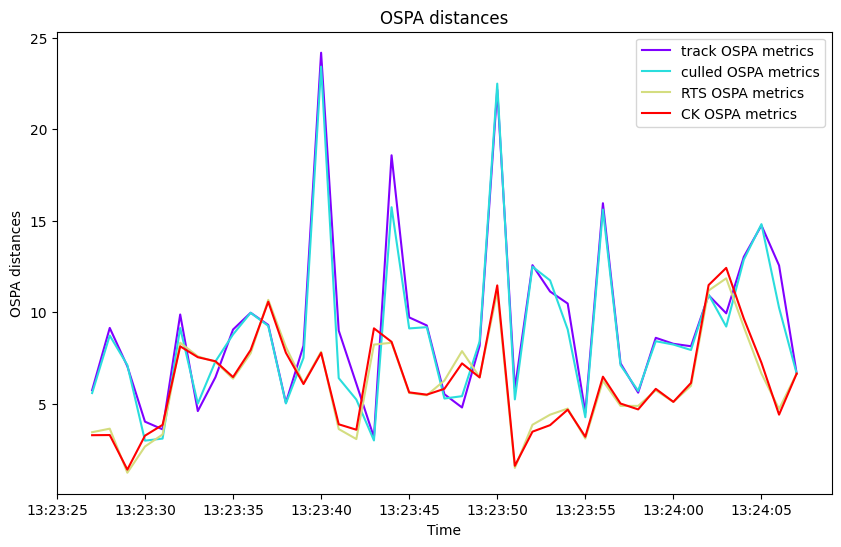

In [22]:
## Generate OSPA plots to see how well each model has tracked the path
tracking_filters = ["track", 
                    "culled",
                    "RTS",
                    "CK"]

from stonesoup.metricgenerator.ospametric import OSPAMetric

ospa_generators = [OSPAMetric(c=40, p=1,
                            generator_name=f'{tracking_filter} OSPA metrics',
                            tracks_key=f'tracks_{tracking_filter}',
                            truths_key='truths'
                            )
                for tracking_filter in tracking_filters]

from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
from stonesoup.measures import Euclidean

siap_generators = [SIAPMetrics(position_measure=Euclidean((0, 2)),
                            velocity_measure=Euclidean((1, 3)),
                            generator_name=f'{tracking_filter} SIAP metrics',
                            tracks_key=f'tracks_{tracking_filter}',
                            truths_key='truths'
                            )
                for tracking_filter in tracking_filters]

from stonesoup.metricgenerator.uncertaintymetric import SumofCovarianceNormsMetric

uncertainty_generators = [
    SumofCovarianceNormsMetric(generator_name=f'{tracking_filter} OSPA metrics',
                            tracks_key=f'tracks_{tracking_filter}')
    for tracking_filter in tracking_filters]

from stonesoup.dataassociator.tracktotrack import TrackToTruth
from stonesoup.metricgenerator.manager import MultiManager

associator = TrackToTruth(association_threshold=30)

generators = ospa_generators #+ siap_generators + uncertainty_generators
metric_manager = MultiManager(generators, associator=associator)

metric_manager.add_data({'truths': [truth],
                        'tracks_track': [track],
                        'tracks_culled': [culled_track],
                        "tracks_RTS": [RTS_track],
                        "tracks_CK":[CK_track]})

metrics = metric_manager.generate_metrics()

from stonesoup.plotter import MetricPlotter

# sum up distance error from ground truth over all timestamps
for tracking_filter in tracking_filters:
    total = sum([metrics[f'{tracking_filter} OSPA metrics']['OSPA distances'].value[i].value
                for i in range(0, len(metrics[f'{tracking_filter} OSPA metrics']['OSPA distances'].value))])
    print(f'OSPA total value for {tracking_filter} is {total:.3f}')

fig1 = MetricPlotter()
fig1.plot_metrics(metrics, metric_names=['OSPA distances'])

## Tutorial References
[1] Lemke, Tatjana, and Simon J. Godsill, 'Inference for models with asymmetric α -stable noise processes', in Siem Jan Koopman, and Neil Shephard (eds), Unobserved Components and Time Series Econometrics (Oxford, 2015; online edn, Oxford Academic, 21 Jan. 2016)

[2] S. Godsill, M. Riabiz, and I. Kontoyiannis, “The L ́evy state space model,” in 2019 53rd Asilomar Conference on Signals, Systems, and Computers, 2019, pp. 487–494.

[3] Cappe, O., Godsill, S.J., and Moulines, E. 2007. "An Overview of Existing Methods and Recent Advances in Sequential Monte Carlo," *Proceedings of the IEEE,* 95(5):899-924. (See smoothing discussion and figures)

[4] Rauch, H. E., Tung, F., and Striebel, C.T. (1965). "Maximum likelihood estimates of linear dynamic systems." *AIAA Journal*, 3(8):1445-1450.

[5] - Carter, C.K., and Kohn, R. (1994). "On Gibbs Sampling for State Space Models," Biometrika, 81(3):541-553.